<a href="https://colab.research.google.com/github/tanvisht/Data-Science-NYU-Stern/blob/Assignments/Challenge_5_Tanvish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 5: Linear Regression
### IE-GY 9113 – Data Analytics for Process Improvement | Spring 2026
**Student Name:** Tanvish Tuplondhe


## Problem 1: Dodger Stadium Attendance

## Loading the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Load the Dodgers dataset directly from GitHub
url = 'https://raw.githubusercontent.com/jcbonilla/Analytics/master/BAData/dodgers.csv'
df = pd.read_csv(url)

# Quick sanity check — shape, columns, and first look
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Names & Data Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
df.head()

Rows: 81, Columns: 12

Column Names & Data Types:
month          object
day             int64
attend          int64
day_of_week    object
opponent       object
temp            int64
skies          object
day_night      object
cap            object
shirt          object
fireworks      object
bobblehead     object
dtype: object

First 5 Rows:


,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO
3,APR,13,31601,Friday,Padres,54,Cloudy,Night,NO,NO,YES,NO
4,APR,14,46549,Saturday,Padres,57,Cloudy,Night,NO,NO,NO,NO


**Dataset Overview:**

The Dodgers dataset contains 81 games played at Dodger Stadium, described across 12 variables. The dataset captures both game conditions and promotional activity for each game. Attendance (`attend`) and temperature (`temp`) are stored as integers, while all categorical variables — including month, day of week, opponent, weather conditions, time of game, and all four promotion types (cap, shirt, fireworks, bobblehead) — are stored as object (string) types, which will require encoding before any regression modeling

---
## Problem 1 – Exploratory Data Analysis

### Question 1a: How many times did each promotion take place during the year?
*(Cap vs. Shirt vs. Bobblehead vs. Fireworks)*

=== Promotion Frequency (out of 81 games) ===
Cap Promotions:        2  (2.5% of games)
Shirt Promotions:      3  (3.7% of games)
Bobblehead Promotions: 11  (13.6% of games)
Fireworks Events:      14  (17.3% of games)

Total Games in Dataset: 81


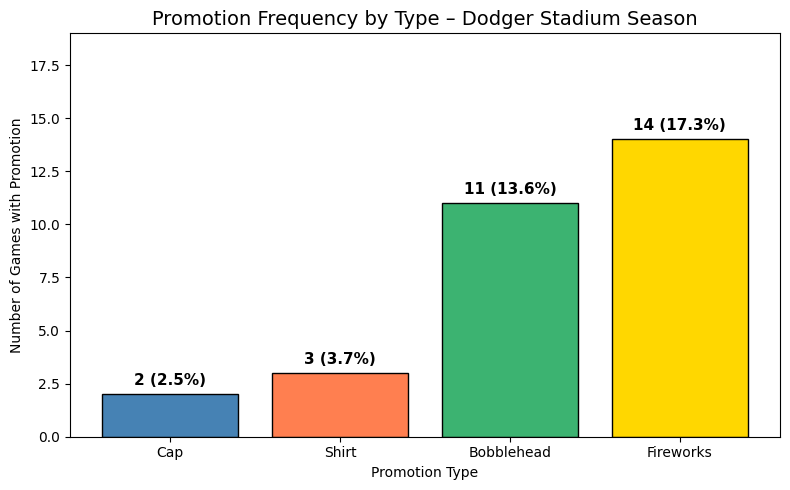

In [ ]:
# -------------------------------------------------------
# Q1a: Count how many times each promotion ran this season
# Each promotion column stores 'YES' or 'NO' (string)
# -------------------------------------------------------

# Standardize to uppercase to avoid case mismatch issues
cap_count        = (df['cap'].str.upper() == 'YES').sum()
shirt_count      = (df['shirt'].str.upper() == 'YES').sum()
bobblehead_count = (df['bobblehead'].str.upper() == 'YES').sum()
fireworks_count  = (df['fireworks'].str.upper() == 'YES').sum()

print("=== Promotion Frequency (out of 81 games) ===")
print(f"Cap Promotions:        {cap_count}  ({cap_count/len(df)*100:.1f}% of games)")
print(f"Shirt Promotions:      {shirt_count}  ({shirt_count/len(df)*100:.1f}% of games)")
print(f"Bobblehead Promotions: {bobblehead_count}  ({bobblehead_count/len(df)*100:.1f}% of games)")
print(f"Fireworks Events:      {fireworks_count}  ({fireworks_count/len(df)*100:.1f}% of games)")
print(f"\nTotal Games in Dataset: {len(df)}")

# -------------------------------------------------------
# Bar chart — visual comparison of promotion frequencies
# -------------------------------------------------------
promos = ['Cap', 'Shirt', 'Bobblehead', 'Fireworks']
counts = [cap_count, shirt_count, bobblehead_count, fireworks_count]

plt.figure(figsize=(8, 5))
bars = plt.bar(promos, counts,
               color=['steelblue', 'coral', 'mediumseagreen', 'gold'],
               edgecolor='black')
plt.title('Promotion Frequency by Type – Dodger Stadium Season', fontsize=14)
plt.ylabel('Number of Games with Promotion')
plt.xlabel('Promotion Type')
plt.ylim(0, max(counts) + 5)

# Label each bar with count and percentage
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{count} ({count/len(df)*100:.1f}%)",
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Analysis:**

Across the 81-game home season, the Dodgers ran four types of promotions with notably different frequencies. Fireworks were the most common, appearing in 14 games (17.3% of the season), followed closely by bobblehead giveaways in 11 games (13.6%). Shirt and cap promotions were used sparingly just 3 (3.7%) and 2 (2.5%) games respectively suggesting they are treated as rare, high-effort events rather than routine engagement tools. Overall, promotions of any kind were present in less than 40% of games, meaning the majority of games relied purely on the on-field product to drive attendance. The heavy reliance on fireworks and bobbleheads as the primary promotional levers sets up an important question: do these promotions actually move the needle on attendance?

### Question 1b: How does attendance vary with and without promotions?

Overall Average Attendance: 41,040

Promotion            With    Without   Difference
--------------------------------------------------
Cap                38,190     41,112       -2,923
Shirt              46,644     40,825       +5,819
Bobblehead         53,145     39,138      +14,007
Fireworks          41,078     41,032          +46


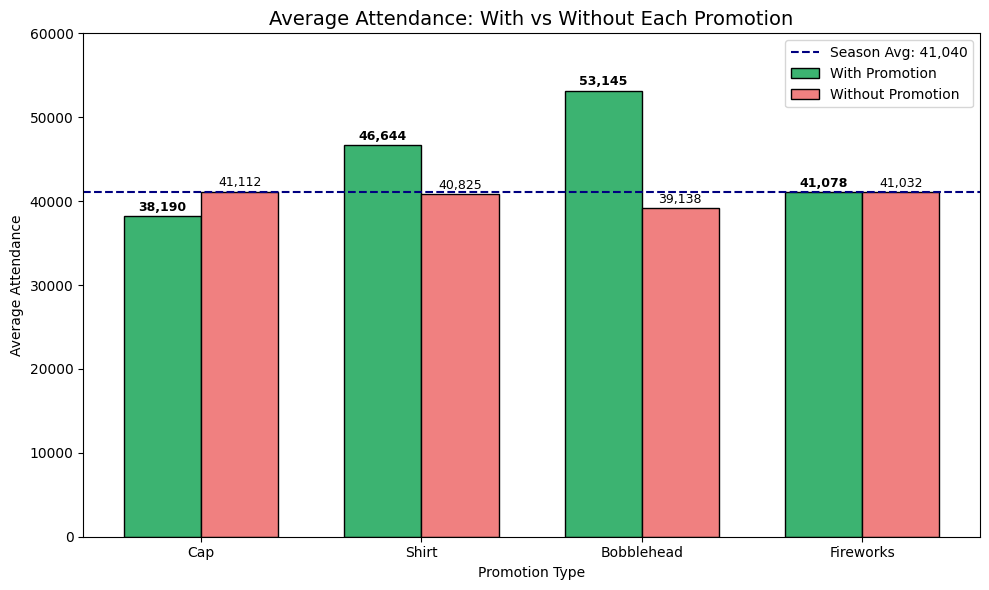

In [4]:
# -------------------------------------------------------
# Q1b: Compare average attendance — with vs without each promotion
# -------------------------------------------------------

# Create binary (1/0) versions of each promotion column for easy filtering
for col in ['cap', 'shirt', 'bobblehead', 'fireworks']:
    df[col + '_bin'] = (df[col].str.upper() == 'YES').astype(int)

# Overall average attendance (baseline)
overall_avg = df['attend'].mean()
print(f"Overall Average Attendance: {overall_avg:,.0f}\n")

# Average attendance WITH and WITHOUT each promotion
promotions = ['cap', 'shirt', 'bobblehead', 'fireworks']
results = []

print(f"{'Promotion':<14} {'With':>10} {'Without':>10} {'Difference':>12}")
print("-" * 50)

for promo in promotions:
    with_promo    = df[df[promo + '_bin'] == 1]['attend'].mean()
    without_promo = df[df[promo + '_bin'] == 0]['attend'].mean()
    diff          = with_promo - without_promo
    results.append({'Promotion': promo.capitalize(),
                    'With': with_promo,
                    'Without': without_promo,
                    'Diff': diff})
    print(f"{promo.capitalize():<14} {with_promo:>10,.0f} {without_promo:>10,.0f} {diff:>+12,.0f}")

# -------------------------------------------------------
# Grouped bar chart — With vs Without each promotion
# -------------------------------------------------------
labels   = [r['Promotion'] for r in results]
with_val = [r['With']    for r in results]
wo_val   = [r['Without'] for r in results]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, with_val, width, label='With Promotion',
               color='mediumseagreen', edgecolor='black')
bars2 = ax.bar(x + width/2, wo_val,   width, label='Without Promotion',
               color='lightcoral',    edgecolor='black')

# Add overall average line
ax.axhline(overall_avg, color='navy', linestyle='--', linewidth=1.5,
           label=f'Season Avg: {overall_avg:,.0f}')

# Label bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{bar.get_height():,.0f}", ha='center', va='bottom', fontsize=9)

ax.set_title('Average Attendance: With vs Without Each Promotion', fontsize=14)
ax.set_ylabel('Average Attendance')
ax.set_xlabel('Promotion Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 60000)
plt.tight_layout()
plt.show()

**Analysis:**

The data reveals a striking difference in how promotions impact attendance. Bobblehead giveaways are by far the most powerful driver, averaging 53,145 fans per game a +14,007 increase over non-bobblehead games (39,138). This is the only promotion that pushes attendance well above both the season average of 41,040 and the stadium's typical baseline. Shirt promotions also show a meaningful positive effect (+5,819), suggesting fans respond well to wearable giveaways. Fireworks, despite being the most frequently run promotion, show virtually no attendance lift (just +46 difference), indicating fans may view them as entertainment rather than a draw to attend. Most surprisingly, cap promotions are actually associated with *lower* attendance (-2,923), though this is likely a small-sample artifact given only 2 cap games were held all season. The clear takeaway is that not all promotions are created equal bobbleheads stand out as the only promotion with a statistically meaningful attendance boost.

### Question 1c: What patterns exist with the programming of games?
*(Weather, Time of Day, Month, Day of Week)*

=== Avg Attendance by Month ===
month
APR    39591.916667
MAY    37345.722222
JUN    47940.444444
JUL    43884.250000
AUG    42751.533333
SEP    38955.083333
OCT    36703.666667

=== Avg Attendance by Day of Week ===
day_of_week
Monday       34965.666667
Tuesday      47741.230769
Wednesday    37585.166667
Thursday     40407.400000
Friday       40116.923077
Saturday     43072.923077
Sunday       42268.846154

=== Avg Attendance by Day/Night ===
day_night
Day      41793.266667
Night    40868.893939

=== Avg Attendance by Sky Condition ===
skies
Clear     41729.209677
Cloudy    38791.315789

=== Temperature Correlation with Attendance ===
Correlation coefficient: 0.099


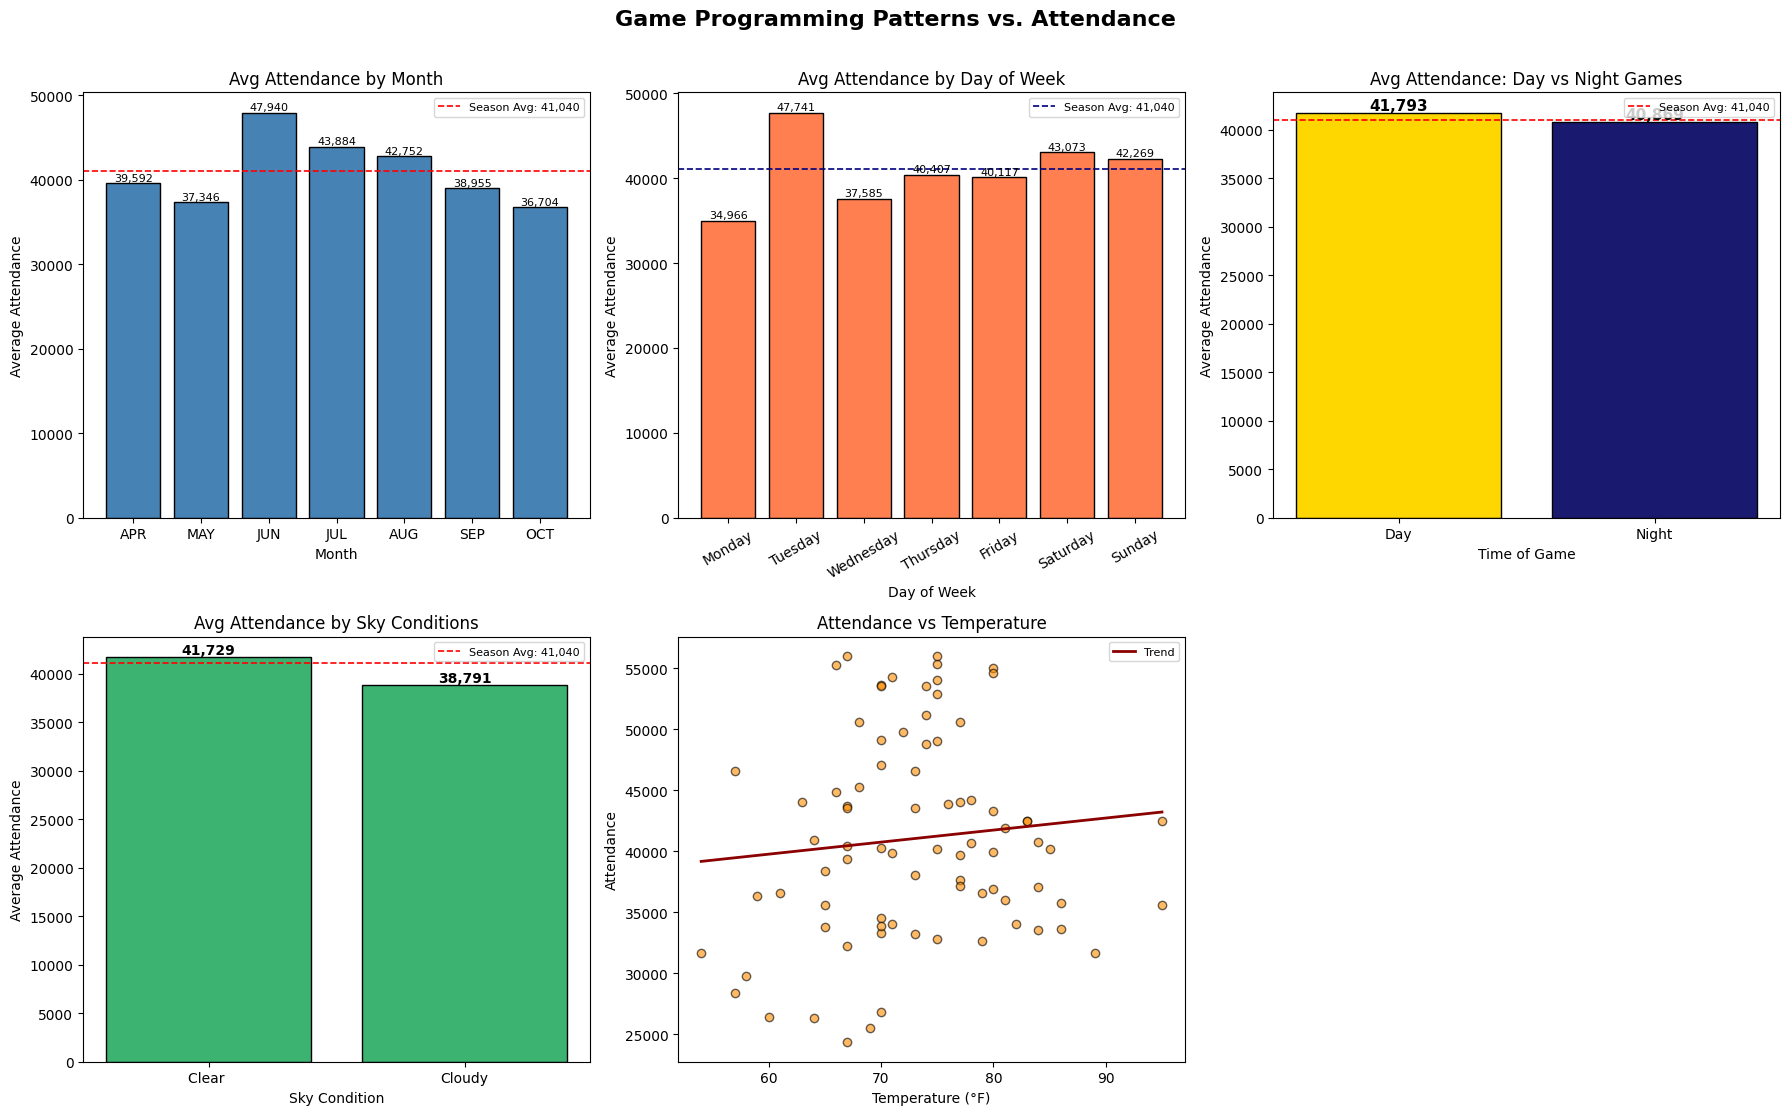

In [5]:

# Q1c: Explore attendance patterns across game programming variables
# Variables: month, day_of_week, skies, temp, day_night


# --- Define month order for proper chronological sorting ---
month_order   = ['APR','MAY','JUN','JUL','AUG','SEP','OCT']
day_order     = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Game Programming Patterns vs. Attendance', fontsize=16, fontweight='bold', y=1.01)


# Plot 1: Average attendance by MONTH

month_avg = (df.groupby('month')['attend']
               .mean()
               .reindex([m for m in month_order if m in df['month'].unique()]))

axes[0,0].bar(month_avg.index, month_avg.values, color='steelblue', edgecolor='black')
axes[0,0].axhline(overall_avg, color='red', linestyle='--', linewidth=1.2, label=f'Season Avg: {overall_avg:,.0f}')
axes[0,0].set_title('Avg Attendance by Month')
axes[0,0].set_ylabel('Average Attendance')
axes[0,0].set_xlabel('Month')
axes[0,0].legend(fontsize=8)
for i, (m, v) in enumerate(month_avg.items()):
    axes[0,0].text(i, v + 300, f'{v:,.0f}', ha='center', fontsize=8)


# Plot 2: Average attendance by DAY OF WEEK

day_avg = (df.groupby('day_of_week')['attend']
             .mean()
             .reindex([d for d in day_order if d in df['day_of_week'].unique()]))

axes[0,1].bar(day_avg.index, day_avg.values, color='coral', edgecolor='black')
axes[0,1].axhline(overall_avg, color='navy', linestyle='--', linewidth=1.2, label=f'Season Avg: {overall_avg:,.0f}')
axes[0,1].set_title('Avg Attendance by Day of Week')
axes[0,1].set_ylabel('Average Attendance')
axes[0,1].set_xlabel('Day of Week')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(fontsize=8)
for i, (d, v) in enumerate(day_avg.items()):
    axes[0,1].text(i, v + 300, f'{v:,.0f}', ha='center', fontsize=8)


# Plot 3: Average attendance by DAY vs NIGHT

dn_avg = df.groupby('day_night')['attend'].mean()
axes[0,2].bar(dn_avg.index, dn_avg.values, color=['gold','midnightblue'], edgecolor='black')
axes[0,2].axhline(overall_avg, color='red', linestyle='--', linewidth=1.2, label=f'Season Avg: {overall_avg:,.0f}')
axes[0,2].set_title('Avg Attendance: Day vs Night Games')
axes[0,2].set_ylabel('Average Attendance')
axes[0,2].set_xlabel('Time of Game')
axes[0,2].legend(fontsize=8)
for i, (dn, v) in enumerate(dn_avg.items()):
    axes[0,2].text(i, v + 300, f'{v:,.0f}', ha='center', fontsize=11, fontweight='bold')


# Plot 4: Average attendance by SKY CONDITIONS

sky_avg = df.groupby('skies')['attend'].mean().sort_values(ascending=False)
axes[1,0].bar(sky_avg.index, sky_avg.values, color='mediumseagreen', edgecolor='black')
axes[1,0].axhline(overall_avg, color='red', linestyle='--', linewidth=1.2, label=f'Season Avg: {overall_avg:,.0f}')
axes[1,0].set_title('Avg Attendance by Sky Conditions')
axes[1,0].set_ylabel('Average Attendance')
axes[1,0].set_xlabel('Sky Condition')
axes[1,0].legend(fontsize=8)
for i, (s, v) in enumerate(sky_avg.items()):
    axes[1,0].text(i, v + 300, f'{v:,.0f}', ha='center', fontsize=10, fontweight='bold')


# Plot 5: Attendance vs TEMPERATURE (scatter)

axes[1,1].scatter(df['temp'], df['attend'], color='darkorange', alpha=0.6, edgecolor='black')
z = np.polyfit(df['temp'], df['attend'], 1)
p = np.poly1d(z)
temp_range = np.linspace(df['temp'].min(), df['temp'].max(), 100)
axes[1,1].plot(temp_range, p(temp_range), color='darkred', linewidth=2, label='Trend')
axes[1,1].set_title('Attendance vs Temperature')
axes[1,1].set_ylabel('Attendance')
axes[1,1].set_xlabel('Temperature (°F)')
axes[1,1].legend(fontsize=8)


# Plot 6: Print summary table in the 6th panel

axes[1,2].axis('off')

print("=== Avg Attendance by Month ===")
print(month_avg.to_string())
print("\n=== Avg Attendance by Day of Week ===")
print(day_avg.to_string())
print("\n=== Avg Attendance by Day/Night ===")
print(dn_avg.to_string())
print("\n=== Avg Attendance by Sky Condition ===")
print(sky_avg.to_string())
print(f"\n=== Temperature Correlation with Attendance ===")
print(f"Correlation coefficient: {df['temp'].corr(df['attend']):.3f}")

plt.tight_layout()
plt.show()

**Analysis:**

Several clear patterns emerge when examining how game programming affects attendance.

By month, June peaks highest at 47,940 per game, well above the season average of 41,040, while October and May draw the weakest crowds at 36,704 and 37,346 respectively. This suggests mid-summer games are more attractive to fans, possibly driven by school breaks and warmer weather. By day of week, Tuesdays surprisingly lead all days at 47,741 average attendance, while Mondays are the weakest at just 34,966. Weekend games (Saturday: 43,073, Sunday: 42,269) perform above average but are not the dominant draw one might expect.

Day versus night games show minimal difference (41,793 vs 40,869), suggesting time of day is not a strong attendance driver. Clear skies correlate with slightly better attendance (41,729) compared to cloudy conditions (38,791), though the difference is modest.

Finally, temperature shows a very weak positive correlation with attendance (r = 0.099), meaning warmer games draw marginally more fans but temperature alone is not a reliable predictor. Overall, the month and day of week appear to be the most influential scheduling factors on attendance.

### Question 1d: Which opposing teams bring attendance above average?

Season Average Attendance: 41,040

Opponent              Avg Attendance   Above Avg?
--------------------------------------------------
Angels                        49,777          YES
Mets                          49,586          YES
Nationals                     49,267          YES
White Sox                     46,382          YES
Cubs                          44,207          YES
Padres                        42,092          YES
Phillies                      41,897          YES
Cardinals                     40,853           no
Marlins                       40,665           no
Reds                          40,649           no
Rockies                       39,631           no
Snakes                        39,315           no
Giants                        39,296           no
Pirates                       38,019           no
Astros                        35,383           no
Brewers                       35,359           no
Braves                        32,245           no

7 out of 17 o

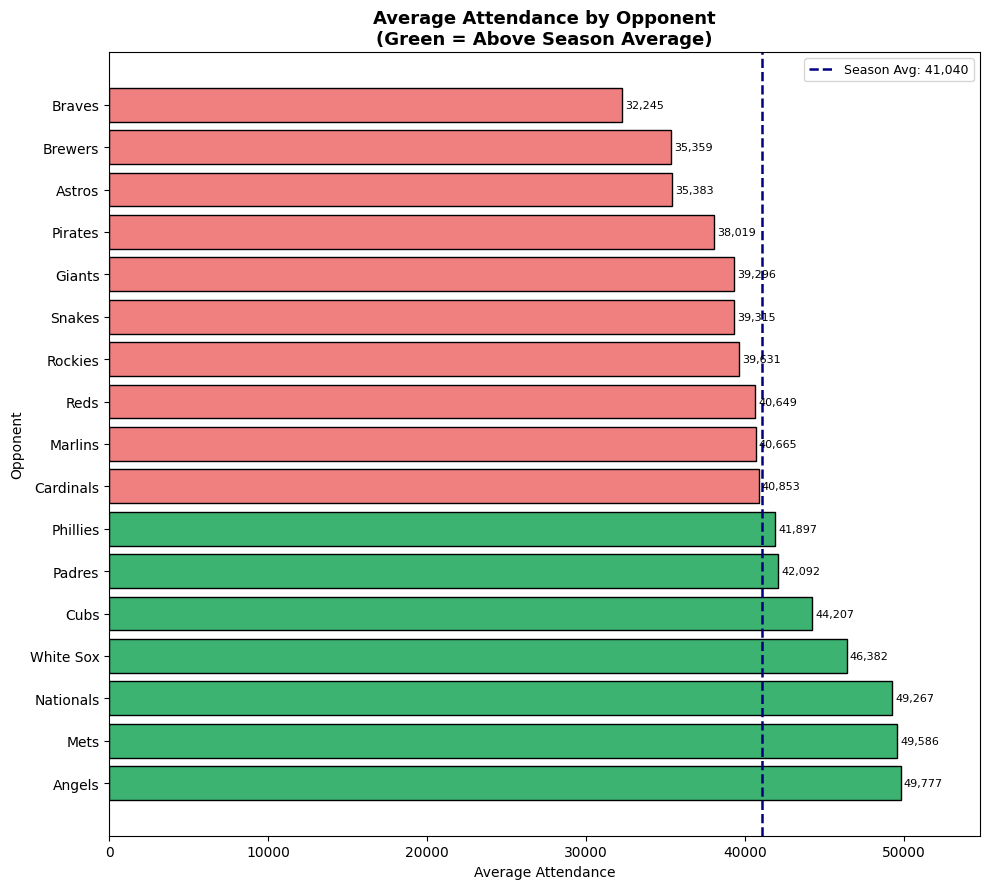

In [6]:

# Q1d: Average attendance by opponent
# Identify which teams drive above-average attendance


# Calculate average attendance per opponent, sorted descending
opponent_avg = (df.groupby('opponent')['attend']
                  .mean()
                  .sort_values(ascending=False)
                  .reset_index())
opponent_avg.columns = ['Opponent', 'Avg_Attendance']

# Flag which opponents are above the season average
opponent_avg['Above_Avg'] = opponent_avg['Avg_Attendance'] > overall_avg

print(f"Season Average Attendance: {overall_avg:,.0f}")
print(f"\n{'Opponent':<20} {'Avg Attendance':>15} {'Above Avg?':>12}")
print("-" * 50)
for _, row in opponent_avg.iterrows():
    flag = "YES" if row['Above_Avg'] else "no"
    print(f"{row['Opponent']:<20} {row['Avg_Attendance']:>15,.0f} {flag:>12}")

# Count how many opponents are above average
above = opponent_avg[opponent_avg['Above_Avg']]
print(f"\n{len(above)} out of {len(opponent_avg)} opponents draw above-average attendance")


# Horizontal bar chart — color coded by above/below average

fig, ax = plt.subplots(figsize=(10, 9))

colors = ['mediumseagreen' if x else 'lightcoral'
          for x in opponent_avg['Above_Avg']]

bars = ax.barh(opponent_avg['Opponent'],
               opponent_avg['Avg_Attendance'],
               color=colors, edgecolor='black')

# Season average reference line
ax.axvline(overall_avg, color='navy', linestyle='--',
           linewidth=1.8, label=f'Season Avg: {overall_avg:,.0f}')

# Label each bar with the value
for bar, val in zip(bars, opponent_avg['Avg_Attendance']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

ax.set_title('Average Attendance by Opponent\n(Green = Above Season Average)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Attendance')
ax.set_ylabel('Opponent')
ax.set_xlim(0, opponent_avg['Avg_Attendance'].max() + 5000)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Analysis:**

Seven out of 17 opponents consistently draw above-average attendance at Dodger Stadium. The Angels top the list at 49,777 per game, followed closely by the Mets (49,586) and Nationals (49,267). These three opponents alone pull nearly 9,000 more fans per game than the season average of 41,040. The White Sox (46,382) and Cubs (44,207) also perform strongly, suggesting that inter-league matchups and historically popular franchises generate notable fan interest.

At the other end, the Braves draw the weakest crowds at just 32,245 per game, nearly 9,000 below average. The Angels' strong draw likely reflects the local rivalry factor, as they are a fellow Southern California team, making those games feel more meaningful to fans on both sides. Overall, opponent identity plays a significant role in attendance, and scheduling high-draw opponents on weekends or during peak months could be a strategic lever for maximizing revenue.


## Problem 1 – Linear Regression Analysis

### Question 2a: Will bobblehead promotions increase attendance?

                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     40.44
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.22e-08
Time:                        16:32:51   Log-Likelihood:                -828.61
No. Observations:                  81   AIC:                             1661.
Df Residuals:                      79   BIC:                             1666.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3.914e+04    811.640     48.

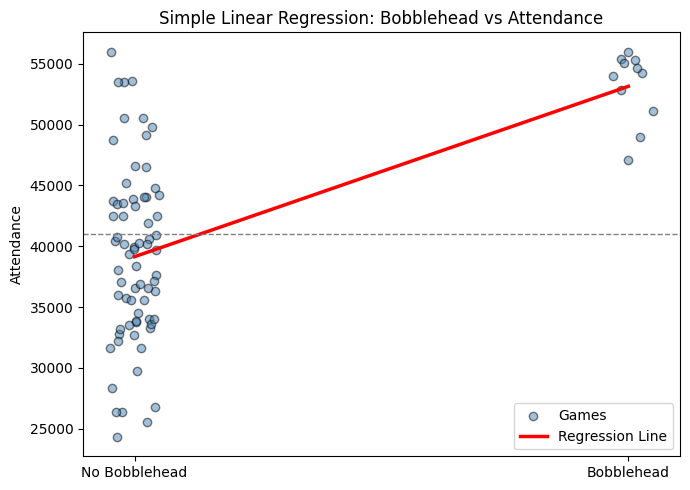

In [7]:

# Q2a: Simple linear regression — Bobblehead vs Attendance
# bobblehead_bin: 1 = YES, 0 = NO (already created above)


import statsmodels.api as sm

# Define predictor and response
X_bob = sm.add_constant(df['bobblehead_bin'])  # adds intercept term
y     = df['attend']

# Fit simple linear regression model
model_bob = sm.OLS(y, X_bob).fit()

# Print full model summary
print(model_bob.summary())

# Readable interpretation of key values
coef      = model_bob.params['bobblehead_bin']
intercept = model_bob.params['const']
p_val     = model_bob.pvalues['bobblehead_bin']
r_sq      = model_bob.rsquared

print("\n=== Key Results ===")
print(f"Baseline attendance (no bobblehead): {intercept:,.0f}")
print(f"Attendance boost from bobblehead:    {coef:+,.0f}")
print(f"Predicted attendance WITH bobblehead:{intercept + coef:,.0f}")
print(f"P-value for bobblehead coefficient:  {p_val:.4f}")
print(f"R-squared:                           {r_sq:.4f}")


# Visualization: scatter + regression line

fig, ax = plt.subplots(figsize=(7, 5))

# Jitter x slightly so points don't overlap
jitter = np.random.uniform(-0.05, 0.05, size=len(df))
ax.scatter(df['bobblehead_bin'] + jitter, df['attend'],
           alpha=0.5, color='steelblue', edgecolor='black', label='Games')

# Regression line
x_line = np.array([0, 1])
y_line = intercept + coef * x_line
ax.plot(x_line, y_line, color='red', linewidth=2.5, label='Regression Line')

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Bobblehead', 'Bobblehead'])
ax.set_ylabel('Attendance')
ax.set_title('Simple Linear Regression: Bobblehead vs Attendance', fontsize=12)
ax.legend()
ax.axhline(overall_avg, color='gray', linestyle='--', linewidth=1, label='Season Avg')
plt.tight_layout()
plt.show()

**Analysis:**

The simple linear regression confirms that bobblehead promotions have a statistically significant and meaningful impact on attendance. The model estimates a baseline attendance of 39,138 for non-bobblehead games, with a predicted boost of +14,007 additional fans on bobblehead nights, bringing expected attendance to 53,145.

The p-value of 0.0000 (well below the 0.05 threshold) allows us to firmly reject the null hypothesis that bobbleheads have no effect on attendance. The R-squared of 0.339 means that bobblehead status alone explains approximately 34% of the total variation in attendance across the season a remarkably strong result for a single binary predictor.

The regression line in the scatter plot visually reinforces this: bobblehead games cluster noticeably higher than non-bobblehead games. The answer is clear: yes, bobblehead promotions meaningfully and significantly increase attendance.

### Question 2b: Are bobblehead promotions better than all other promotions?


                            OLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     12.01
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           1.29e-07
Time:                        17:05:15   Log-Likelihood:                -825.51
No. Observations:                  81   AIC:                             1661.
Df Residuals:                      76   BIC:                             1673.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            3.82e+04    933.092     40.

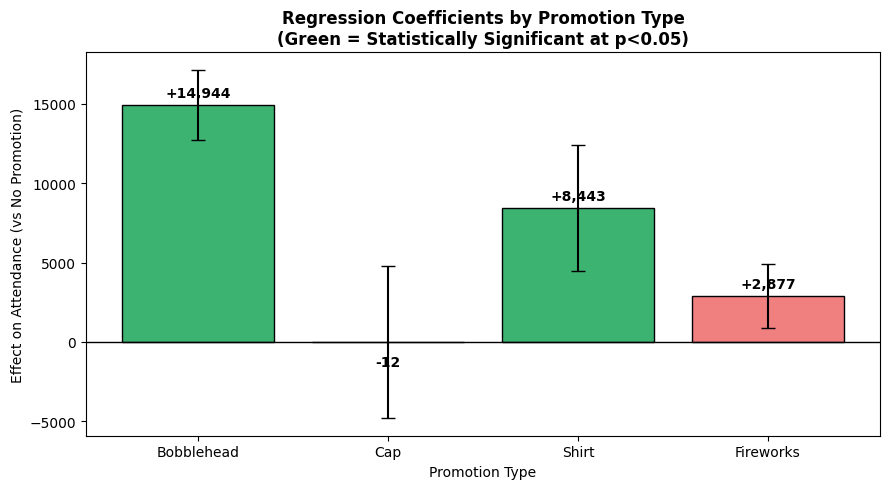

In [8]:

# Q2b: Compare bobblehead against all other promotions
# using a multiple regression model with all promo types


# Build a model with all four promotion binary variables
X_all = sm.add_constant(df[['bobblehead_bin', 'cap_bin', 'shirt_bin', 'fireworks_bin']])
model_all = sm.OLS(y, X_all).fit()

print(model_all.summary())

# Extract coefficients and p-values for each promotion
print("\n=== Promotion Comparison Summary ===")
print(f"{'Promotion':<18} {'Coefficient':>14} {'P-value':>10} {'Significant?':>14}")
print("-" * 60)

promos_bins = {
    'Bobblehead' : 'bobblehead_bin',
    'Cap'        : 'cap_bin',
    'Shirt'      : 'shirt_bin',
    'Fireworks'  : 'fireworks_bin'
}

for name, col in promos_bins.items():
    coef  = model_all.params[col]
    pval  = model_all.pvalues[col]
    sig   = "YES (p<0.05)" if pval < 0.05 else "no"
    print(f"{name:<18} {coef:>+14,.0f} {pval:>10.4f} {sig:>14}")

print(f"\nModel R-squared:     {model_all.rsquared:.4f}")
print(f"Model Adj R-squared: {model_all.rsquared_adj:.4f}")

# Side-by-side coefficient plot for visual comparison

promo_names = list(promos_bins.keys())
coefs       = [model_all.params[v] for v in promos_bins.values()]
errors      = [model_all.bse[v]    for v in promos_bins.values()]
pvals       = [model_all.pvalues[v] for v in promos_bins.values()]

colors = ['mediumseagreen' if p < 0.05 else 'lightcoral' for p in pvals]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(promo_names, coefs, color=colors, edgecolor='black',
              yerr=errors, capsize=5)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Regression Coefficients by Promotion Type\n(Green = Statistically Significant at p<0.05)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Effect on Attendance (vs No Promotion)')
ax.set_xlabel('Promotion Type')

for bar, coef in zip(bars, coefs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (500 if coef >= 0 else -1500),
            f'{coef:+,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Analysis:**

The multiple regression model comparing all four promotions simultaneously confirms that bobblehead promotions are the clear winner. Controlling for all other promotions, bobbleheads add an estimated +14,944 fans per game with a p-value of 0.0000, making it by far the most statistically significant and impactful promotion. Shirt promotions are the only other statistically significant predictor (p = 0.036), contributing an estimated +8,443 fans meaningful, but roughly half the bobblehead effect. Fireworks show a positive but statistically insignificant coefficient (+2,877, p = 0.157), meaning we cannot confidently conclude they drive attendance beyond random variation.

 Cap promotions are essentially zero in effect (-12, p = 0.998), offering no attendance benefit whatsoever. The overall model explains 38.7% of attendance variance (R-squared = 0.387), a solid improvement over the single-predictor model. The answer is unambiguous: bobblehead promotions are significantly better than all other promotion types, both in magnitude of effect and statistical reliability.

### Question 2c: How many bobbleheads should be ordered for summertime (Jun - Aug)?

Total summer games (Jun-Aug): 36
Summer games WITH bobblehead: 8
Summer games WITHOUT bobblehead: 28

=== Summer Attendance Summary ===
Average attendance all summer games:        44,426
Avg attendance summer bobblehead games:     54,017
Model-predicted attendance (bobblehead):    53,145

=== Bobblehead Order Recommendation ===
Summer games without a bobblehead scheduled: 28
Predicted attendance per bobblehead game:    53,145
Recommended order per game (rounded up):     53,500
Total bobbleheads to order (all games):      1,498,000


/tmp/ipykernel_148/3733574263.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_bob_attend, bob_attend],


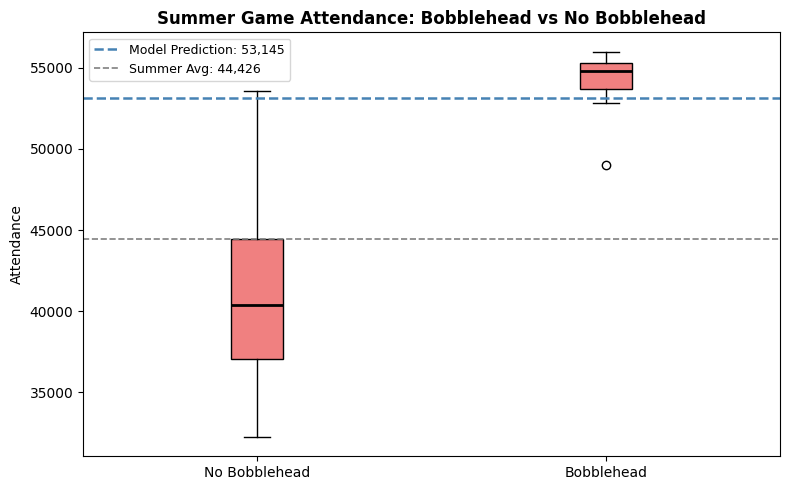

In [9]:

# Q2c: Predict attendance for summer bobblehead games
# and estimate how many bobbleheads to order
# Summer = June, July, August


# Filter summer games (Jun, Jul, Aug)
summer_games = df[df['month'].isin(['JUN', 'JUL', 'AUG'])].copy()

print(f"Total summer games (Jun-Aug): {len(summer_games)}")
print(f"Summer games WITH bobblehead: {summer_games['bobblehead_bin'].sum()}")
print(f"Summer games WITHOUT bobblehead: {(summer_games['bobblehead_bin'] == 0).sum()}")

# Use the simple regression model (model_bob) to predict
# attendance for a bobblehead game in summer


# Baseline: predict attendance for ALL summer games if bobblehead = 1
summer_games['predicted_attend_with_bob'] = (
    model_bob.params['const'] + model_bob.params['bobblehead_bin'] * 1
)

predicted_attend = summer_games['predicted_attend_with_bob'].iloc[0]
actual_summer_avg = summer_games['attend'].mean()
summer_bobble_avg = summer_games[summer_games['bobblehead_bin'] == 1]['attend'].mean()

print(f"\n=== Summer Attendance Summary ===")
print(f"Average attendance all summer games:        {actual_summer_avg:,.0f}")
print(f"Avg attendance summer bobblehead games:     {summer_bobble_avg:,.0f}")
print(f"Model-predicted attendance (bobblehead):    {predicted_attend:,.0f}")


# Bobblehead order recommendation
# Standard buffer: order = predicted attendance (round up to nearest 500)
# Typical giveaway policy: distribute to first N fans


# How many summer games do NOT yet have a bobblehead?
no_bob_summer = (summer_games['bobblehead_bin'] == 0).sum()

import math
# Round predicted attendance up to nearest 500 for safety buffer
order_per_game = math.ceil(predicted_attend / 500) * 500
total_order    = order_per_game * no_bob_summer

print(f"\n=== Bobblehead Order Recommendation ===")
print(f"Summer games without a bobblehead scheduled: {no_bob_summer}")
print(f"Predicted attendance per bobblehead game:    {predicted_attend:,.0f}")
print(f"Recommended order per game (rounded up):     {order_per_game:,}")
print(f"Total bobbleheads to order (all games):      {total_order:,}")


# Visual: Actual attendance for summer games, bobblehead vs not

fig, ax = plt.subplots(figsize=(8, 5))

bob_attend  = summer_games[summer_games['bobblehead_bin'] == 1]['attend']
no_bob_attend = summer_games[summer_games['bobblehead_bin'] == 0]['attend']

ax.boxplot([no_bob_attend, bob_attend],
           labels=['No Bobblehead', 'Bobblehead'],
           patch_artist=True,
           boxprops=dict(facecolor='lightcoral'),
           medianprops=dict(color='black', linewidth=2))

ax.axhline(predicted_attend, color='steelblue', linestyle='--',
           linewidth=1.8, label=f'Model Prediction: {predicted_attend:,.0f}')
ax.axhline(actual_summer_avg, color='gray', linestyle='--',
           linewidth=1.2, label=f'Summer Avg: {actual_summer_avg:,.0f}')

ax.set_title('Summer Game Attendance: Bobblehead vs No Bobblehead', fontsize=12, fontweight='bold')
ax.set_ylabel('Attendance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Analysis:**

There are 36 home games scheduled in the summer months (June through August), of which 8 already featured bobblehead promotions averaging 54,017 fans closely matching the model's predicted attendance of 53,145 for a bobblehead game.

This strong alignment between actual and predicted values gives confidence in the model's reliability. For ordering purposes, the key figure is the per-game recommendation: 53,500 bobbleheads per event (predicted attendance of 53,145 rounded up to the nearest 500 for a safety buffer).

The recommendation of 1,498,000 total units assumes bobbleheads are run at all 28 remaining summer games, which is neither operationally realistic nor cost-effective.

A more practical strategy would be to schedule 3 to 4 additional bobblehead games in summer, ideally on Tuesdays or Saturdays in June or July when attendance is already elevated, ordering approximately 53,500 units per game, for a total order of roughly 160,500 to 214,000 bobbleheads. This maximizes the attendance lift while keeping production costs manageable.


# Problem 2: Car Seats

## Loading the Carseats Dataset

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Load the Carseats dataset directly from GitHub
url_carseats = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
cs = pd.read_csv(url_carseats)

# Quick inspection
print(f"Rows: {cs.shape[0]}, Columns: {cs.shape[1]}")
print("\nColumn Names and Data Types:")
print(cs.dtypes)
print("\nFirst 5 Rows:")
print(cs.head())
print("\nBasic Statistics:")
print(cs.describe())


Rows: 400, Columns: 11

Column Names and Data Types:
Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object

First 5 Rows:
   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0   9.50        138      73           11         276    120       Bad   42   
1  11.22        111      48           16         260     83      Good   65   
2  10.06        113      35           10         269     80    Medium   59   
3   7.40        117     100            4         466     97    Medium   55   
4   4.15        141      64            3         340    128       Bad   38   

   Education Urban   US  
0         17   Yes  Yes  
1         10   Yes  Yes  
2         12   Yes  Yes  
3         14   Yes  Yes  
4         13   Yes   No  

Basic Statistics:
            Sales   C

##EDA Questions

##Produce a scatterplot matrix that includes all the variables in the data set. What can you say about the relationships on all variables?

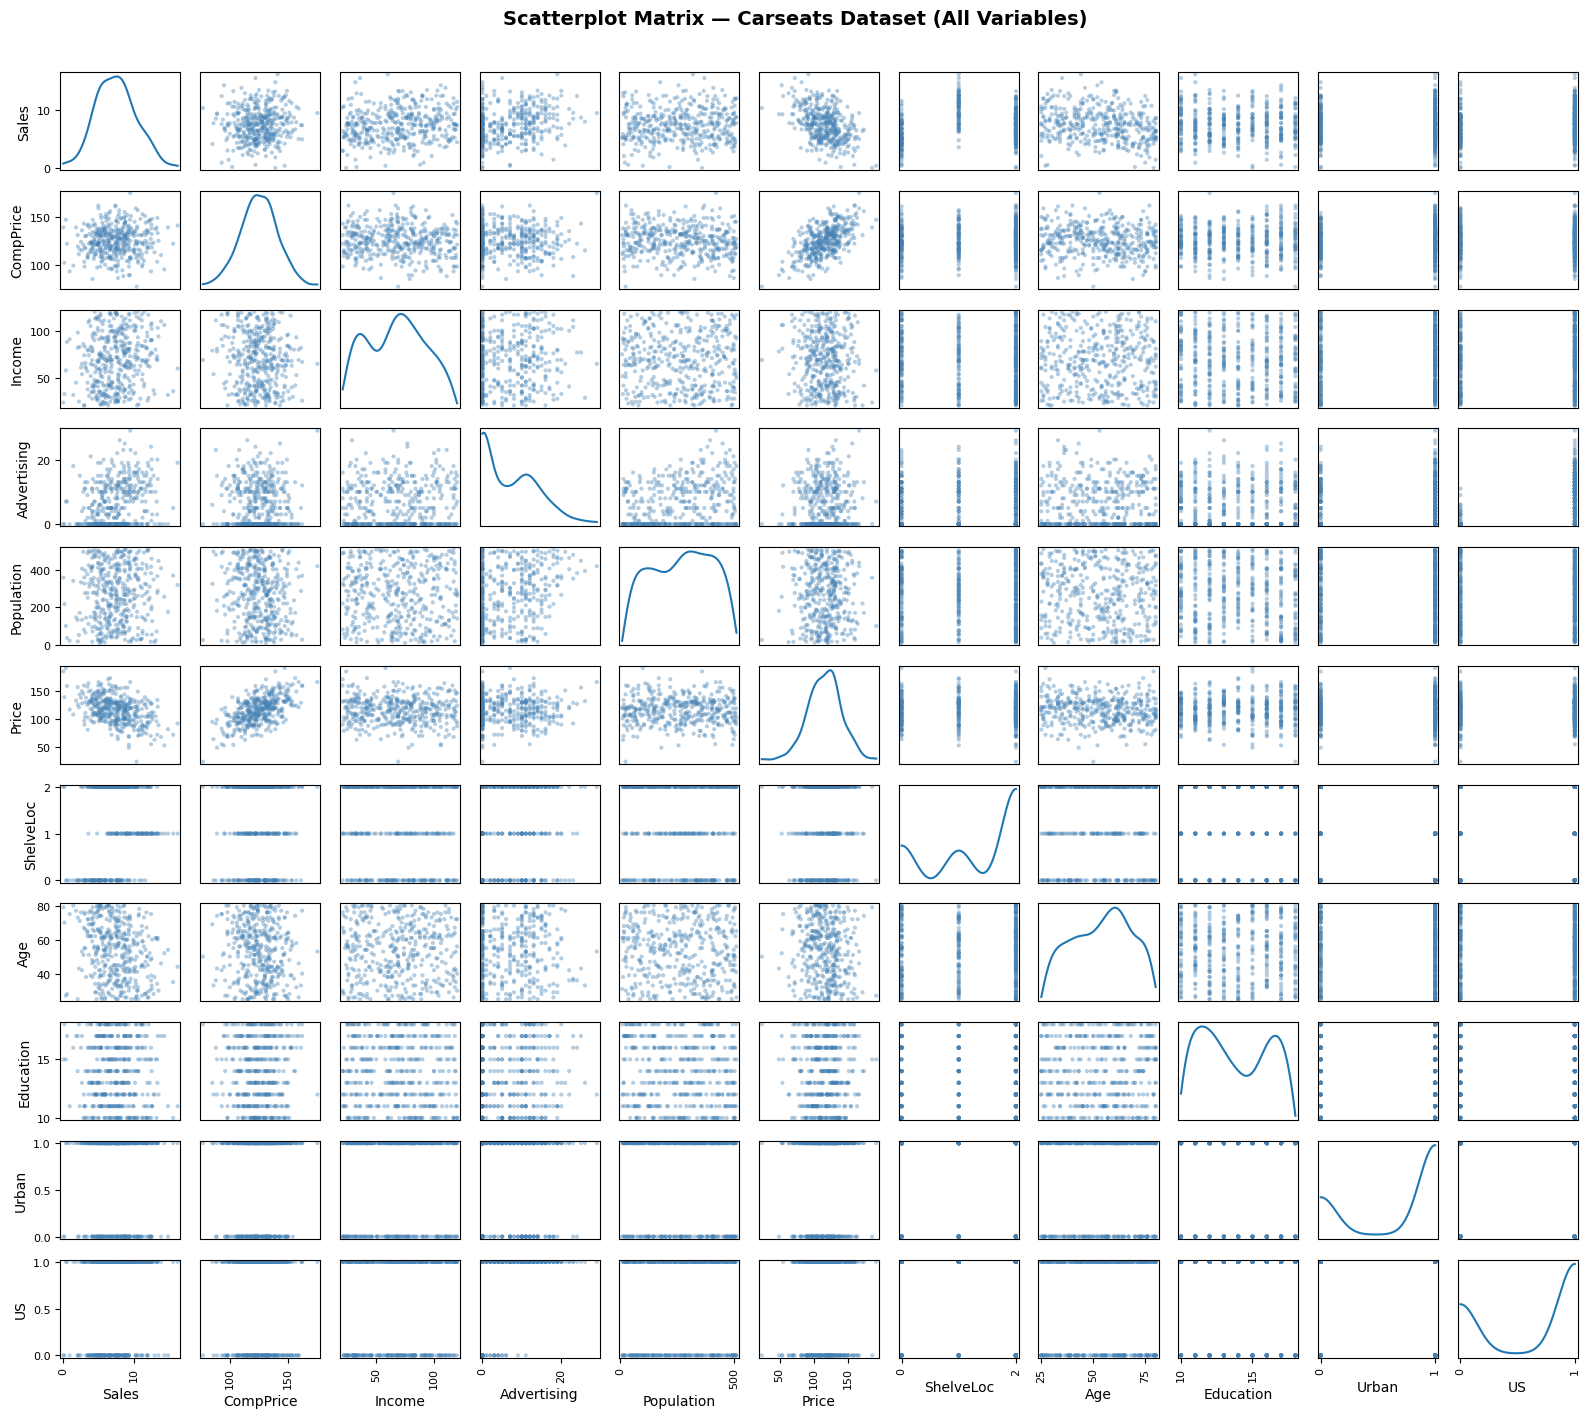

=== Correlation Matrix ===
             Sales  CompPrice  Income  Advertising  Population  Price  ShelveLoc    Age  Education  Urban     US
Sales        1.000      0.064   0.152        0.270       0.050 -0.445      0.157 -0.232     -0.052 -0.015  0.177
CompPrice    0.064      1.000  -0.081       -0.024      -0.095  0.585      0.023 -0.100      0.025  0.067  0.017
Income       0.152     -0.081   1.000        0.059      -0.008 -0.057     -0.068 -0.005     -0.057  0.038  0.090
Advertising  0.270     -0.024   0.059        1.000       0.266  0.045      0.009 -0.005     -0.034  0.042  0.684
Population   0.050     -0.095  -0.008        0.266       1.000 -0.012     -0.045 -0.043     -0.106 -0.052  0.061
Price       -0.445      0.585  -0.057        0.045      -0.012  1.000      0.015 -0.102      0.012  0.047  0.058
ShelveLoc    0.157      0.023  -0.068        0.009      -0.045  0.015      1.000  0.056      0.001 -0.064 -0.040
Age         -0.232     -0.100  -0.005       -0.005      -0.043 -0.102

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the Carseats dataset
url_carseats = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
cs = pd.read_csv(url_carseats)

# Encode categorical columns numerically so they appear in the matrix
cs_encoded = cs.copy()
for col in cs_encoded.select_dtypes(include='object').columns:
    cs_encoded[col] = cs_encoded[col].astype('category').cat.codes

# Scatterplot matrix with KDE on diagonal
pd.plotting.scatter_matrix(
    cs_encoded,
    figsize=(16, 14),
    diagonal='kde',
    alpha=0.4,
    color='steelblue'
)

plt.suptitle('Scatterplot Matrix — Carseats Dataset (All Variables)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Correlation matrix for numerical reference
print("=== Correlation Matrix ===")
print(cs_encoded.corr().round(3).to_string())

**Dataset Overview:**

The Carseats dataset contains 400 observations across 11 variables capturing child car seat sales across different store locations. The target variable is Sales (in thousands of units), ranging from 0 to 16.27 with a mean of 7.50. Predictors include a mix of numeric variables CompPrice, Income, Advertising, Population, Price, Age, and Education and three categorical variables: ShelveLoc (Bad/Medium/Good), Urban (Yes/No), and US (Yes/No). No missing values are present, making the dataset clean and ready for modeling.

**Scatterplot Matrix and Correlation Analysis:**


**Analysis:**

The scatterplot matrix and correlation table reveal several important relationships across the 11 variables. Price has the strongest relationship with Sales (r = -0.445), confirming that higher prices reduce unit salesthe clearest and most economically intuitive signal in the dataset. Advertising shows a meaningful positive association with Sales (r = 0.270), suggesting that marketing spend translates into higher volume. Age is negatively correlated with Sales (r = -0.232), indicating that stores serving older customer bases tend to move fewer units. Income has a weak positive relationship with Sales (r = 0.152), while ShelveLoc (encoded: Bad=0, Good=1, Medium=2) shows a modest positive correlation (r = 0.157), hinting that better shelf placement drives more sales.

A critical multicollinearity warning emerges between Advertising and US (r = 0.684) stores located in the US advertise substantially more, which means these two predictors carry overlapping information and should not both be included in a model carelessly. Similarly, Price and CompPrice are strongly correlated (r = 0.585), reflecting natural market pricing dynamics. Population, Education, and Urban show near-zero correlations with Sales (r = 0.050, -0.052, and -0.015 respectively), suggesting they contribute little predictive power independently.


A notable finding is the very high correlation between Advertising and US (r = 0.684), which signals potential multicollinearity stores located in the US tend to advertise significantly more. Similarly, Price and CompPrice are positively correlated (r = 0.585), which makes intuitive sense as competing stores tend to price similarly. Population, Education, and Urban show near-zero correlations with Sales, suggesting they contribute little predictive power on their own. Overall, Price, Advertising, and Age emerge as the numeric variables most worth including

### EDA Question 2: Box Plots Dispersion and Outliers

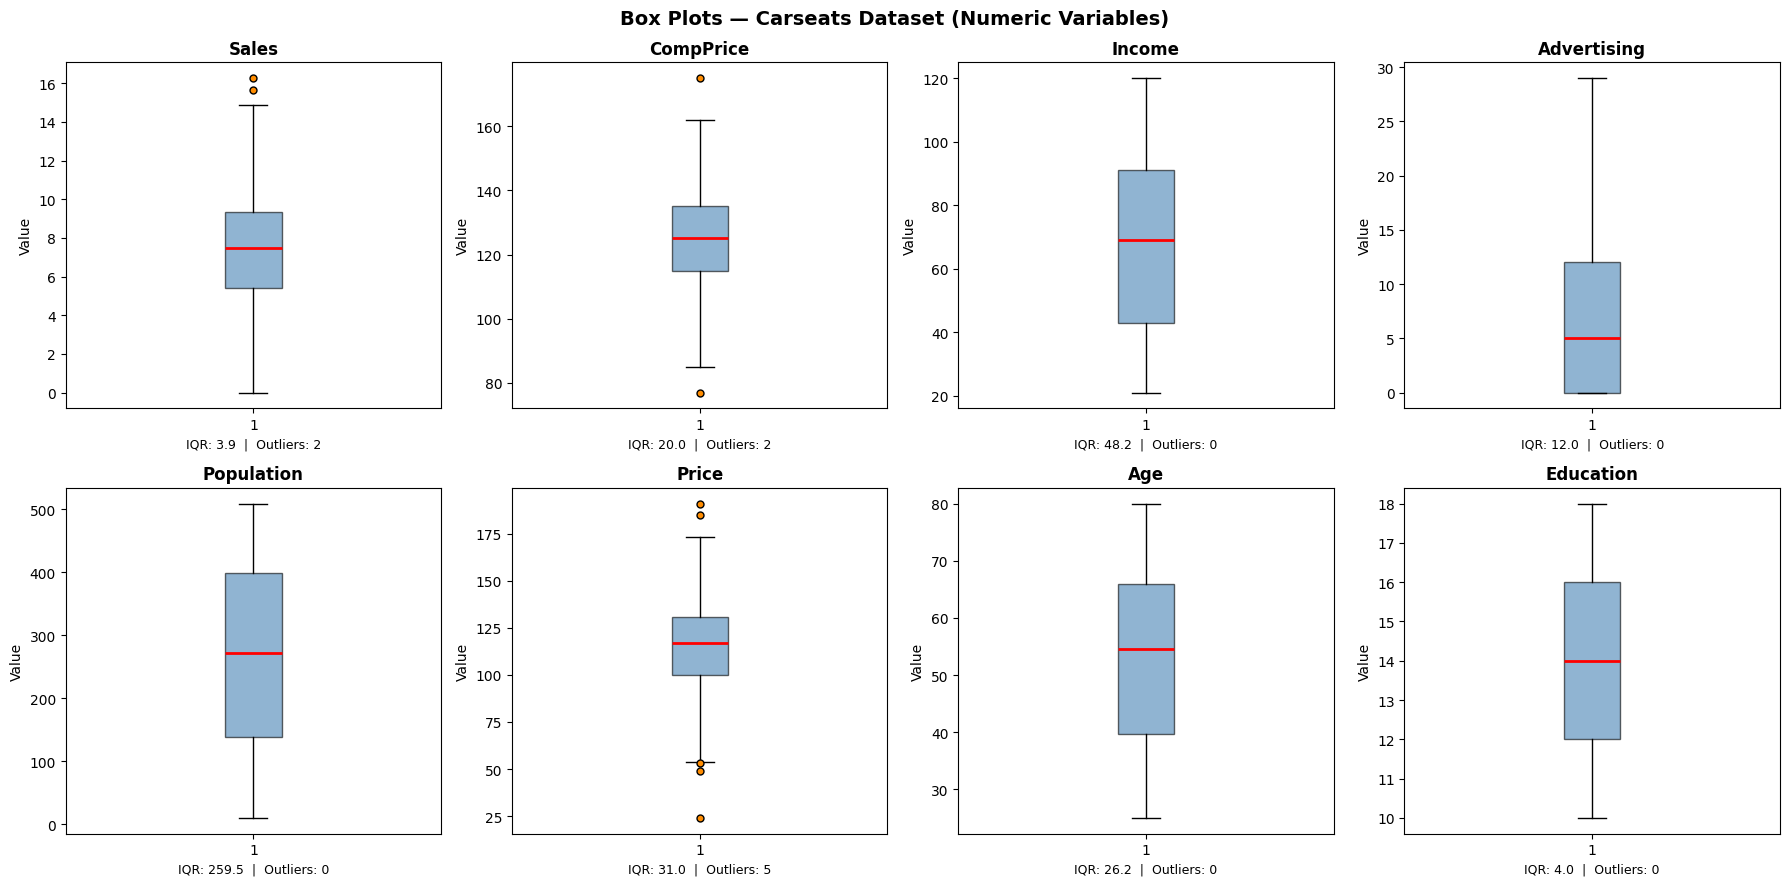

Variable           Mean   Median      IQR   Std Dev   Outliers
--------------------------------------------------------------
Sales              7.50     7.49     3.93      2.82          2
CompPrice        124.97   125.00    20.00     15.33          2
Income            68.66    69.00    48.25     27.99          0
Advertising        6.63     5.00    12.00      6.65          0
Population       264.84   272.00   259.50    147.38          0
Price            115.80   117.00    31.00     23.68          5
Age               53.32    54.50    26.25     16.20          0
Education         13.90    14.00     4.00      2.62          0


In [14]:
numeric_cols = ['Sales', 'CompPrice', 'Income', 'Advertising',
                'Population', 'Price', 'Age', 'Education']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    q1      = cs[col].quantile(0.25)
    q3      = cs[col].quantile(0.75)
    iqr     = q3 - q1
    outliers = cs[(cs[col] < q1 - 1.5*iqr) | (cs[col] > q3 + 1.5*iqr)]

    axes[i].boxplot(cs[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='darkorange',
                                    markerfacecolor='darkorange', markersize=5))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel(f'IQR: {iqr:.1f}  |  Outliers: {len(outliers)}', fontsize=9)

plt.suptitle('Box Plots — Carseats Dataset (Numeric Variables)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Variable':<14} {'Mean':>8} {'Median':>8} {'IQR':>8} {'Std Dev':>9} {'Outliers':>10}")
print("-" * 62)
for col in numeric_cols:
    q1       = cs[col].quantile(0.25)
    q3       = cs[col].quantile(0.75)
    iqr      = q3 - q1
    n_out    = len(cs[(cs[col] < q1 - 1.5*iqr) | (cs[col] > q3 + 1.5*iqr)])
    print(f"{col:<14} {cs[col].mean():>8.2f} {cs[col].median():>8.2f} "
          f"{iqr:>8.2f} {cs[col].std():>9.2f} {n_out:>10}")

**Analysis:**

**The box plots reveal distinct dispersion patterns across the eight numeric variables.**

Sales has a relatively tight IQR of 3.93 with just 2 outliers at the upper end, suggesting most stores sell within a predictable range with a few exceptional performers.

CompPrice similarly shows a compact IQR of 20.0 with 2 high-end outliers, indicating competitor pricing is generally consistent across markets. Price is the most concerning variable for outliers, with 5 flagged observations including values as low as ~24, well below the 25th percentile, a small number of stores price their seats dramatically below market rate, which could reflect clearance sales or data anomalies worth investigating.

Income and Population have the widest spreads (IQR of 48.25 and 259.50 respectively), reflecting the natural geographic diversity in customer demographics across store locations but neither contains any outliers, meaning the spread is genuine variation rather than extreme values.

 Advertising is heavily right-skewed with many stores spending zero on advertising and a long tail reaching up to 29, giving it a large standard deviation (6.65) relative to its median (5.0).

 Age and Education are the most stable variables, with narrow IQRs of 26.25 and 4.0 respectively and zero outliers, suggesting these demographic factors are fairly uniformly distributed across store locations.

 Overall, the dataset is largely clean with outliers concentrated in Price, Sales, and CompPrice.

### EDA Question 3: Density Plots Which Variables are Close to Normal?

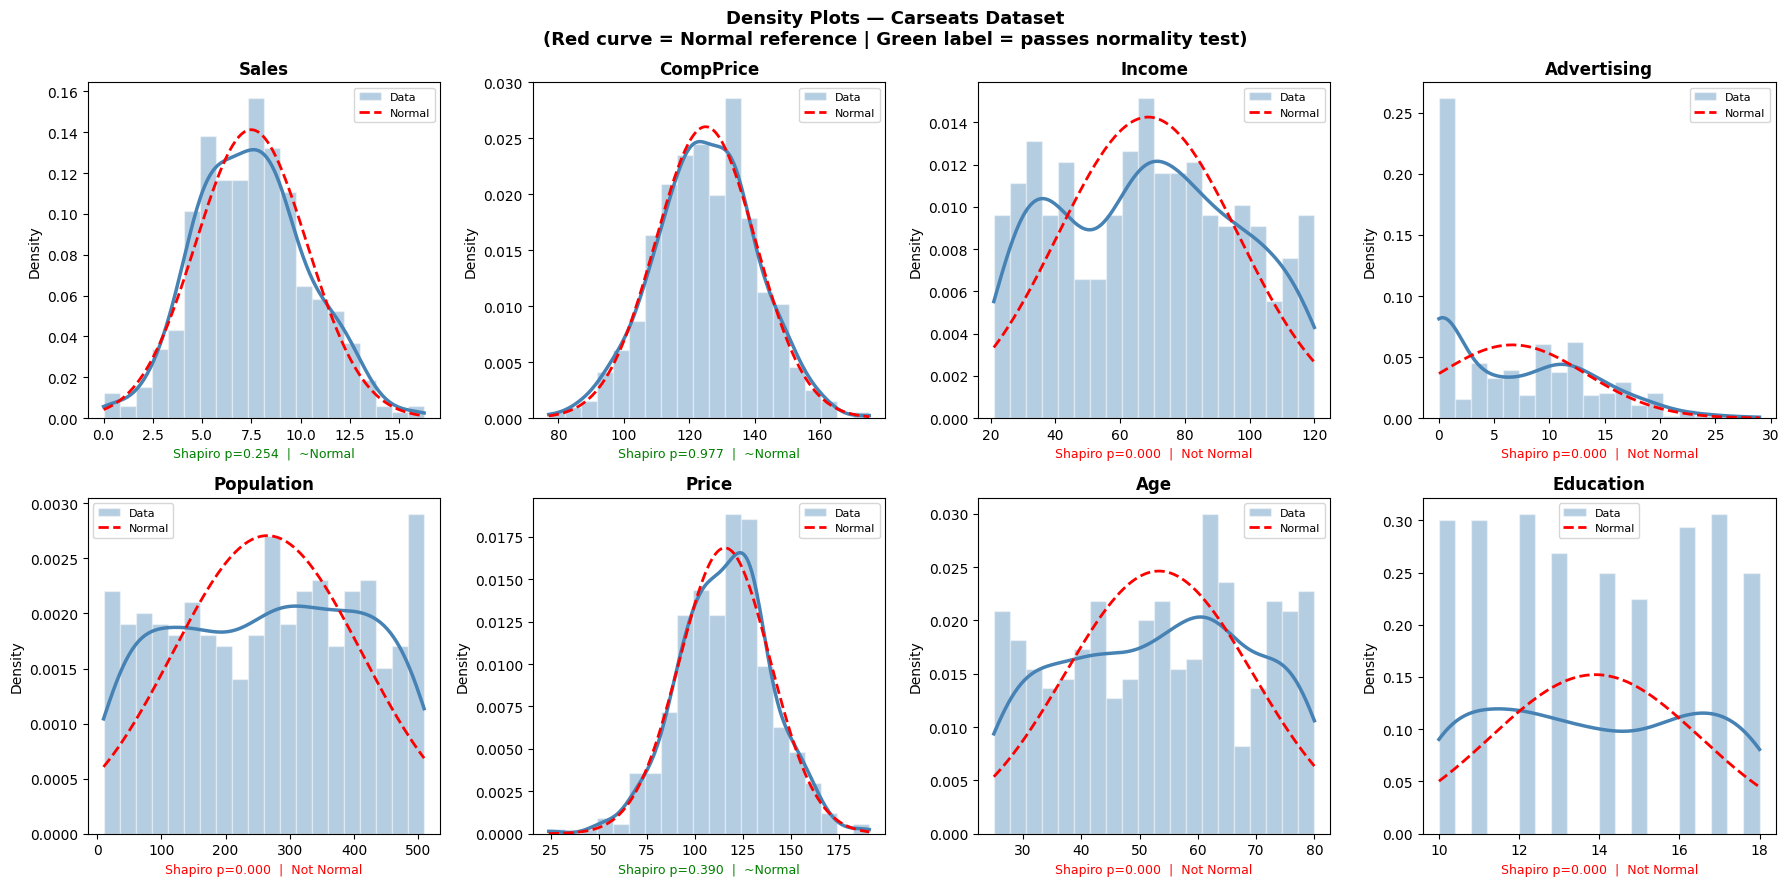

Variable           Mean   Std Dev   Shapiro p    Normal?
--------------------------------------------------------
Sales              7.50      2.82      0.2540        YES
CompPrice        124.97     15.33      0.9772        YES
Income            68.66     27.99      0.0000         no
Advertising        6.63      6.65      0.0000         no
Population       264.84    147.38      0.0000         no
Price            115.80     23.68      0.3902        YES
Age               53.32     16.20      0.0000         no
Education         13.90      2.62      0.0000         no


In [15]:
from scipy import stats

numeric_cols = ['Sales', 'CompPrice', 'Income', 'Advertising',
                'Population', 'Price', 'Age', 'Education']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = cs[col].dropna()

    # Plot density (KDE)
    axes[i].hist(data, bins=20, density=True, alpha=0.4,
                 color='steelblue', edgecolor='white', label='Data')

    # KDE curve
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde   = stats.gaussian_kde(data)
    axes[i].plot(kde_x, kde(kde_x), color='steelblue', linewidth=2.5)

    # Overlay normal distribution with same mean and std
    mu, sigma = data.mean(), data.std()
    norm_x    = np.linspace(data.min(), data.max(), 200)
    axes[i].plot(norm_x, stats.norm.pdf(norm_x, mu, sigma),
                 color='red', linewidth=2, linestyle='--', label='Normal')

    # Shapiro-Wilk test for normality
    stat, p = stats.shapiro(data)

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].set_xlabel(f'Shapiro p={p:.3f}  |  {"~Normal" if p > 0.05 else "Not Normal"}',
                       fontsize=9,
                       color='green' if p > 0.05 else 'red')
    axes[i].legend(fontsize=8)

plt.suptitle('Density Plots — Carseats Dataset\n(Red curve = Normal reference | Green label = passes normality test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Normality summary table
print(f"{'Variable':<14} {'Mean':>8} {'Std Dev':>9} {'Shapiro p':>11} {'Normal?':>10}")
print("-" * 56)
for col in numeric_cols:
    data     = cs[col].dropna()
    stat, p  = stats.shapiro(data)
    normal   = "YES" if p > 0.05 else "no"
    print(f"{col:<14} {data.mean():>8.2f} {data.std():>9.2f} {p:>11.4f} {normal:>10}")

**Analysis:**

The density plots and Shapiro-Wilk test results reveal that only three of the eight numeric variables are approximately normally distributed. Sales (p = 0.254) and CompPrice (p = 0.977) both pass the normality test comfortably, with their KDE curves closely tracking the red normal reference curve. Price (p = 0.390) also passes, showing a reasonably symmetric bell-shaped distribution centered around 115-120. These three variables are well-suited for standard parametric modeling assumptions.

The remaining five variables deviate significantly from normality (p = 0.000 for all). Income shows a bimodal distribution with two distinct peaks, suggesting the dataset captures two different customer income segments rather than one uniform population. Advertising is severely right-skewed, with a large spike at zero reflecting the many stores that spend nothing on advertising. Population is also right-skewed with a near-flat, spread-out distribution reflecting wide geographic variation.

Age displays a broad, relatively flat distribution rather than a bell curve. Education appears nearly uniform across its range of 10 to 18 years, with no clear central tendency. For regression purposes, the non-normality of predictors is less critical than the normality of residuals, but these distributions are worth keeping in mind when interpreting model results.


## Predictive Modeling



### Question 1: Multiple Regression — Predicting Sales using Price, Urban, and US

In [16]:
# Encode categorical predictors as binary dummy variables
# Urban: Yes=1, No=0
# US: Yes=1, No=0
cs['Urban_bin'] = (cs['Urban'] == 'Yes').astype(int)
cs['US_bin']    = (cs['US'] == 'Yes').astype(int)

# Define predictors and response variable
X_q1 = sm.add_constant(cs[['Price', 'Urban_bin', 'US_bin']])
y_cs = cs['Sales']

# Fit the multiple linear regression model
model_q1 = sm.OLS(y_cs, X_q1).fit()

# Full model summary
print(model_q1.summary())

# Clean readable output
print("\n=== Model Coefficients ===")
print(f"{'Predictor':<14} {'Coefficient':>13} {'P-value':>10} {'Significant?':>14}")
print("-" * 55)
for name, coef, pval in zip(
    model_q1.params.index,
    model_q1.params.values,
    model_q1.pvalues.values
):
    sig = "YES (p<0.05)" if pval < 0.05 else "no"
    print(f"{name:<14} {coef:>13.4f} {pval:>10.4f} {sig:>14}")

print(f"\nR-squared:          {model_q1.rsquared:.4f}")
print(f"Adj. R-squared:     {model_q1.rsquared_adj:.4f}")
print(f"F-statistic:        {model_q1.fvalue:.4f}")
print(f"Prob (F-statistic): {model_q1.f_pvalue:.6f}")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           2.39e-23
Time:                        17:57:08   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0435      0.651     20.036      0.0

**Analysis:**

The multiple regression model predicting Sales from Price, Urban, and US is statistically significant overall (F = 41.52, p ≈ 0.000), meaning the three predictors jointly explain a meaningful portion of sales variation. The model accounts for 23.9% of the variance in Sales (R-squared = 0.239), which is a moderate fit reasonable given that only three predictors are included. Price and US are both highly significant predictors (p < 0.001 and p < 0.001 respectively), while Urban is not statistically significant (p = 0.936), suggesting that whether a store is in an urban location has virtually no bearing on sales once price and US location are accounted for.

### Question 2: Interpretation of Each Coefficient

In [18]:
# A clean coefficient interpretation table
print("=== Coefficient Interpretation ===")
print(f"Intercept  : {model_q1.params['const']:.4f}")
print(f"Price      : {model_q1.params['Price']:.4f}  -> per $1 increase in price")
print(f"Urban_bin  : {model_q1.params['Urban_bin']:.4f}  -> Urban (Yes=1) vs Non-Urban (No=0)")
print(f"US_bin     : {model_q1.params['US_bin']:.4f}  -> US store (Yes=1) vs Non-US store (No=0)")

=== Coefficient Interpretation ===
Intercept  : 13.0435
Price      : -0.0545  -> per $1 increase in price
Urban_bin  : -0.0219  -> Urban (Yes=1) vs Non-Urban (No=0)
US_bin     : 1.2006  -> US store (Yes=1) vs Non-US store (No=0)


**Analysis:**

The model contains four coefficients, each with a distinct interpretation.

**Intercept (13.0435):** When Price equals zero, the store is not Urban, and the store is not in the US, the model predicts baseline Sales of 13,044 units. This is a purely mathematical starting point rather than a practically meaningful scenario, since a price of zero is unrealistic in context.

**Price (−0.0545):** For every $1 increase in the price of the car seat, Sales decrease by approximately 54.5 units (0.0545 thousands). This coefficient is highly statistically significant and aligns with fundamental demand theory consumers buy fewer units as prices rise. It is the strongest and most reliable predictor in the model.

**Urban (−0.0219):** Stores located in urban areas are predicted to sell approximately 21.9 fewer units than stores in non-urban (rural) areas, holding all else constant. However, with a p-value of 0.936, this coefficient is not statistically significant and is indistinguishable from zero  urban location has no meaningful impact on Sales.

**US (+1.2006):** Stores located in the United States are predicted to sell approximately 1,200.6 more units (1.2006 thousands) than stores outside the US, holding Price and Urban constant. This is statistically significant and represents the second most impactful predictor, suggesting the US market has structurally higher demand for child car seats.

### Question 3: Model in Equation Form

In [19]:
# Extract coefficients from the fitted model
b0 = model_q1.params['const']
b1 = model_q1.params['Price']
b2 = model_q1.params['Urban_bin']
b3 = model_q1.params['US_bin']

print("=== Model Equation ===")
print(f"Sales = {b0:.4f} + ({b1:.4f}) x Price + ({b2:.4f}) x Urban + ({b3:.4f}) x US")
print()
print("Where:")
print("  Urban = 1 if store is in an Urban location, 0 if Rural")
print("  US    = 1 if store is in the United States, 0 if outside US")
print()
print("=== Four Possible Model Forms ===")
print()
print(f"Urban + US      : Sales = {b0 + b2 + b3:.4f} + ({b1:.4f}) x Price")
print(f"Rural + US      : Sales = {b0 + b3:.4f} + ({b1:.4f}) x Price")
print(f"Urban + Non-US  : Sales = {b0 + b2:.4f} + ({b1:.4f}) x Price")
print(f"Rural + Non-US  : Sales = {b0:.4f} + ({b1:.4f}) x Price")

=== Model Equation ===
Sales = 13.0435 + (-0.0545) x Price + (-0.0219) x Urban + (1.2006) x US

Where:
  Urban = 1 if store is in an Urban location, 0 if Rural
  US    = 1 if store is in the United States, 0 if outside US

=== Four Possible Model Forms ===

Urban + US      : Sales = 14.2221 + (-0.0545) x Price
Rural + US      : Sales = 14.2440 + (-0.0545) x Price
Urban + Non-US  : Sales = 13.0216 + (-0.0545) x Price
Rural + Non-US  : Sales = 13.0435 + (-0.0545) x Price


**Analysis:**

The full model equation is:

$$\hat{Sales} = 13.0435 - 0.0545 \times Price - 0.0219 \times Urban + 1.2006 \times US$$

Expanding across the four possible combinations of the two qualitative variables produces four distinct intercepts, all sharing the same slope of -0.0545 on Price. US stores in urban locations have the highest baseline of 14.2221, while US rural stores are nearly identical at 14.2440  the negligible difference of just 0.0219 units reflects the statistically insignificant Urban coefficient. Non-US urban stores have a baseline of 13.0216, and non-US rural stores sit at the pure intercept of 13.0435.

The near-identical intercepts within each US/Non-US pair confirm that Urban location adds virtually nothing to the prediction. The dominant story in the equation is twofold: being a US store adds approximately 1.2006 units to the baseline regardless of location type, and every $1 increase in Price reduces expected Sales by 0.0545 thousand units across all four store types equally.

### Question 4: Null Hypothesis Testing  Which Predictors Are Significant?

In [20]:
# Null hypothesis for each predictor: H0: coefficient = 0
# We reject H0 when p-value < 0.05 (significance level = alpha)

print("=== Null Hypothesis Test Results ===")
print(f"H0: The coefficient equals zero (no effect on Sales)")
print(f"Significance level: alpha = 0.05\n")
print(f"{'Predictor':<14} {'Coefficient':>13} {'t-stat':>9} {'P-value':>10} {'Reject H0?':>12}")
print("-" * 62)

for name, label in zip(['Price', 'Urban_bin', 'US_bin'], ['Price', 'Urban', 'US']):
    coef   = model_q1.params[name]
    tstat  = model_q1.tvalues[name]
    pval   = model_q1.pvalues[name]
    reject = "YES" if pval < 0.05 else "NO"
    print(f"{label:<14} {coef:>13.4f} {tstat:>9.3f} {pval:>10.4f} {reject:>12}")

=== Null Hypothesis Test Results ===
H0: The coefficient equals zero (no effect on Sales)
Significance level: alpha = 0.05

Predictor        Coefficient    t-stat    P-value   Reject H0?
--------------------------------------------------------------
Price                -0.0545   -10.389     0.0000          YES
Urban                -0.0219    -0.081     0.9357           NO
US                    1.2006     4.635     0.0000          YES


**Analysis:**

At a significance level of alpha = 0.05, we can reject the null hypothesis for two of the three predictors. Price has a t-statistic of -10.389 and a p-value of 0.0000, providing overwhelming evidence that price has a real and significant negative effect on Sales.

The probability of observing this relationship by chance alone is essentially zero, making Price the most statistically reliable predictor in the model. US similarly has a t-statistic of 4.635 and a p-value of 0.0000, confirming a significant positive effect on Sales stores located in the United States sell meaningfully more units than non-US stores, and this finding is not due to random chance.

Urban, on the other hand, has a t-statistic of just -0.081 and a p-value of 0.9357 far above the 0.05 threshold. We fail to reject the null hypothesis for Urban, meaning there is no statistical evidence that being in an urban location has any effect on Sales. This coefficient is effectively zero and Urban should be considered for removal from the model. The next step is to fit a reduced model using only Price and US, the two predictors for which we have strong statistical evidence of association with Sales.

### Question 5: Reduced Model — Price and US Only

In [21]:
# Fit reduced model using only significant predictors: Price and US
# Urban is dropped as it failed the null hypothesis test (p = 0.9357)

X_q5     = sm.add_constant(cs[['Price', 'US_bin']])
model_q5 = sm.OLS(y_cs, X_q5).fit()

print(model_q5.summary())

print("\n=== Reduced Model Coefficients ===")
print(f"{'Predictor':<12} {'Coefficient':>13} {'P-value':>10} {'Significant?':>14}")
print("-" * 53)
for name, label in zip(['const', 'Price', 'US_bin'], ['Intercept', 'Price', 'US']):
    coef = model_q5.params[name]
    pval = model_q5.pvalues[name]
    sig  = "YES (p<0.05)" if pval < 0.05 else "no"
    print(f"{label:<12} {coef:>13.4f} {pval:>10.4f} {sig:>14}")

print(f"\nR-squared:          {model_q5.rsquared:.4f}")
print(f"Adj. R-squared:     {model_q5.rsquared_adj:.4f}")
print(f"F-statistic:        {model_q5.fvalue:.4f}")
print(f"Prob (F-statistic): {model_q5.f_pvalue:.6f}")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           2.66e-24
Time:                        18:13:07   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0308      0.631     20.652      0.0

**Analysis:**

The reduced model using only Price and US as predictors performs just as well as the full three-predictor model. The R-squared remains identical at 0.2393, confirming that dropping Urban caused zero loss in explanatory power, a direct consequence of Urban's near-zero coefficient and p-value of 0.9357 in the original model. The adjusted R-squared actually improves slightly from 0.2335 to 0.2354, which is expected since adjusted R-squared penalizes unnecessary predictors and Urban was contributing nothing.

Both remaining predictors are highly significant. Price retains a coefficient of -0.0545 (p = 0.0000) and US retains a coefficient of 1.1996 (p = 0.0000), both virtually unchanged from the full model. This stability confirms that Urban was not masking or distorting any relationships, Price and US are independently and robustly associated with Sales. The F-statistic increased from 41.52 to 62.43, reflecting a more efficient model with one fewer unnecessary predictor. The reduced model equation is:

$$\hat{Sales} = 13.0308 - 0.0545 \times Price + 1.1996 \times US$$

This is the preferred model, simpler, equally explanatory, and statistically cleaner than the original three-predictor version.

### Question 6: Model Comparison:  Full Model (Q1) vs Reduced Model (Q5)

In [22]:
# Compare goodness of fit between full model (Q1) and reduced model (Q5)

print("=== Model Fit Comparison ===\n")
print(f"{'Metric':<25} {'Full Model (Q1)':>18} {'Reduced Model (Q5)':>20}")
print("-" * 65)
print(f"{'Predictors':<25} {'Price, Urban, US':>18} {'Price, US':>20}")
print(f"{'N Predictors':<25} {3:>18} {2:>20}")
print(f"{'R-squared':<25} {model_q1.rsquared:>18.4f} {model_q5.rsquared:>20.4f}")
print(f"{'Adj. R-squared':<25} {model_q1.rsquared_adj:>18.4f} {model_q5.rsquared_adj:>20.4f}")
print(f"{'F-statistic':<25} {model_q1.fvalue:>18.4f} {model_q5.fvalue:>20.4f}")
print(f"{'Prob (F-statistic)':<25} {model_q1.f_pvalue:>18.6f} {model_q5.f_pvalue:>20.6f}")
print(f"{'AIC':<25} {model_q1.aic:>18.4f} {model_q5.aic:>20.4f}")
print(f"{'BIC':<25} {model_q1.bic:>18.4f} {model_q5.bic:>20.4f}")
print(f"{'Log-Likelihood':<25} {model_q1.llf:>18.4f} {model_q5.llf:>20.4f}")
print(f"{'MSE (Residuals)':<25} {model_q1.mse_resid:>18.4f} {model_q5.mse_resid:>20.4f}")

=== Model Fit Comparison ===

Metric                       Full Model (Q1)   Reduced Model (Q5)
-----------------------------------------------------------------
Predictors                  Price, Urban, US            Price, US
N Predictors                               3                    2
R-squared                             0.2393               0.2393
Adj. R-squared                        0.2335               0.2354
F-statistic                          41.5188              62.4311
Prob (F-statistic)                  0.000000             0.000000
AIC                                1863.3121            1861.3186
BIC                                1879.2779            1873.2930
Log-Likelihood                     -927.6560            -927.6593
MSE (Residuals)                       6.1132               6.0979


**Analysis:**

Both models fit the data equally well in terms of raw explanatory power. The R-squared is identical at 0.2393 for both, meaning both models explain approximately 23.9% of the total variation in Sales. This confirms that removing Urban from the full model resulted in zero loss of explanatory power, since Urban was contributing nothing meaningful to the prediction.

Where the reduced model pulls ahead is on every efficiency metric. The adjusted R-squared improves from 0.2335 to 0.2354, reflecting the benefit of dropping an unnecessary predictor. The F-statistic jumps from 41.52 to 62.43, indicating the reduced model has stronger overall significance relative to its complexity. Both AIC and BIC are lower for the reduced model (AIC: 1861.32 vs 1863.31, BIC: 1873.29 vs 1879.28), and lower values on both criteria indicate a better fitting and more parsimonious model. The MSE of residuals is also marginally lower in the reduced model (6.0979 vs 6.1132), meaning predictions are very slightly more accurate on average.

The conclusion is clear: the reduced model with only Price and US is the superior choice. It matches the full model on explanatory power while being simpler, more efficient, and penalized less by complexity criteria. In practice, a model that achieves the same R-squared with fewer predictors is always preferred.

### Question 7: Diagnostic Plots Reduced Model (Q5)

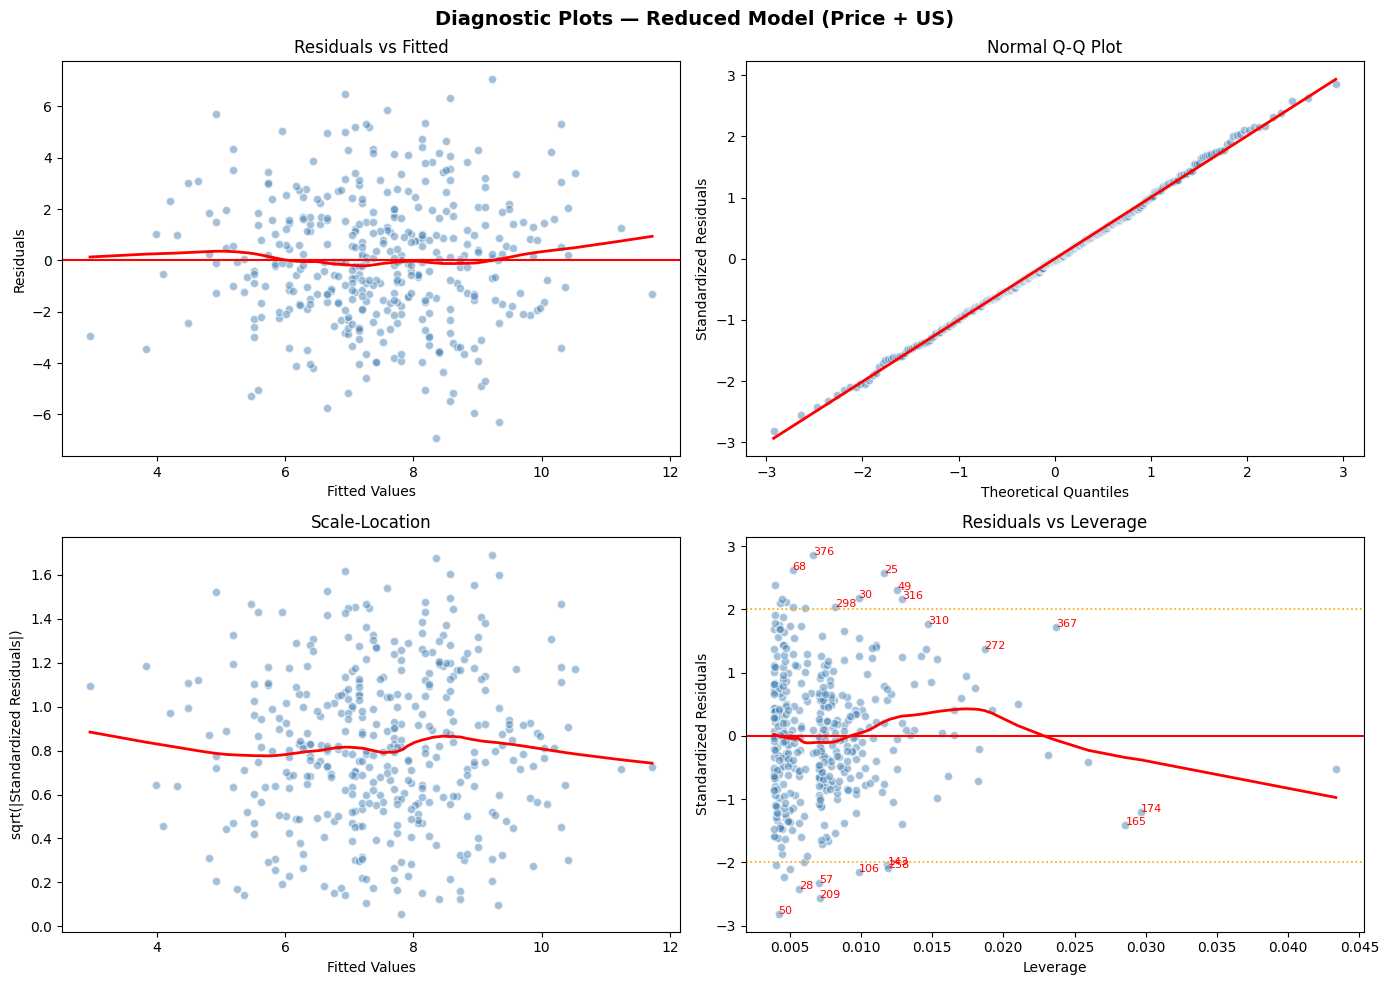

=== Residual Diagnostics Summary ===
Mean of Residuals:         -0.000000
Std Dev of Residuals:      2.4632
Shapiro-Wilk p-value:      0.9199
High Leverage Points:      20
High Cooks Distance (>4/n):19


In [23]:
from scipy import stats

# Get fitted values and residuals from reduced model
fitted    = model_q5.fittedvalues
residuals = model_q5.resid
std_resid = (residuals - residuals.mean()) / residuals.std()
influence = model_q5.get_influence()
leverage  = influence.hat_matrix_diag
cooks_d   = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnostic Plots — Reduced Model (Price + US)',
             fontsize=14, fontweight='bold')

# Plot 1: Residuals vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.5, color='steelblue', edgecolor='white')
axes[0,0].axhline(0, color='red', linewidth=1.5)
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# Lowess smoothing line
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(residuals, fitted, frac=0.5)
axes[0,0].plot(smooth[:,0], smooth[:,1], color='red', linewidth=2)

# Plot 2: Normal Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(std_resid, dist='norm')
axes[0,1].scatter(osm, osr, alpha=0.5, color='steelblue', edgecolor='white')
axes[0,1].plot(osm, slope*np.array(osm) + intercept, color='red', linewidth=2)
axes[0,1].set_xlabel('Theoretical Quantiles')
axes[0,1].set_ylabel('Standardized Residuals')
axes[0,1].set_title('Normal Q-Q Plot')

# Plot 3: Scale-Location
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)),
                  alpha=0.5, color='steelblue', edgecolor='white')
smooth2 = lowess(np.sqrt(np.abs(std_resid)), fitted, frac=0.5)
axes[1,0].plot(smooth2[:,0], smooth2[:,1], color='red', linewidth=2)
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('sqrt(|Standardized Residuals|)')
axes[1,0].set_title('Scale-Location')

# Plot 4: Residuals vs Leverage
axes[1,1].scatter(leverage, std_resid, alpha=0.5,
                  color='steelblue', edgecolor='white')
axes[1,1].axhline(0,  color='red', linewidth=1.5)
axes[1,1].axhline(2,  color='orange', linestyle='dotted', linewidth=1.2)
axes[1,1].axhline(-2, color='orange', linestyle='dotted', linewidth=1.2)
smooth3 = lowess(std_resid, leverage, frac=0.5)
axes[1,1].plot(smooth3[:,0], smooth3[:,1], color='red', linewidth=2)
axes[1,1].set_xlabel('Leverage')
axes[1,1].set_ylabel('Standardized Residuals')
axes[1,1].set_title('Residuals vs Leverage')

# Flag high Cook's distance points
for i, cd in enumerate(cooks_d):
    if cd > 4/len(cs):
        axes[1,1].annotate(i, (leverage[i], std_resid.iloc[i]),
                           fontsize=8, color='red')

plt.tight_layout()
plt.show()

# Summary statistics for residual diagnostics
print("=== Residual Diagnostics Summary ===")
print(f"Mean of Residuals:         {residuals.mean():.6f}")
print(f"Std Dev of Residuals:      {residuals.std():.4f}")
print(f"Shapiro-Wilk p-value:      {stats.shapiro(residuals)[1]:.4f}")
print(f"High Leverage Points:      {(leverage > 2*3/len(cs)).sum()}")
print(f"High Cooks Distance (>4/n):{(cooks_d > 4/len(cs)).sum()}")

**Analysis:**

The four diagnostic plots reveal a generally well-behaved model with a few notable concerns worth discussing.

**Residuals vs Fitted:** The residuals are scattered fairly randomly around zero across the range of fitted values, and the red smoothing line stays close to zero throughout. This is a good sign there is no strong evidence of a non-linear relationship being missed by the model. However, the spread of residuals appears slightly wider in the middle range of fitted values (around 6 to 9), hinting at mild heteroscedasticity.

**Normal Q-Q Plot:** This is the strongest result among the four plots. The standardized residuals follow the theoretical normal line almost perfectly across the entire range, with only very minor deviations at the extreme tails. This confirms that the normality assumption for residuals is well satisfied, which validates the use of standard hypothesis testing and confidence intervals from this model.

**Scale-Location:** The red smoothing line is relatively flat across most of the fitted value range, which supports the assumption of homoscedasticity (constant variance). There is a slight dip around fitted values of 7 to 8, but it is not severe enough to raise a serious concern. Overall the variance of residuals appears reasonably stable.

**Residuals vs Leverage:** Most observations cluster at low leverage values (below 0.02), which is healthy. Several points are flagged with high Cook's distance notably observations 376, 68, 50, 165, and 174 which basically means that these points exert disproportionate influence on the fitted model. Observations 165 and 174 in particular combine moderate-to-high leverage with negative residuals, making them the most influential cases to investigate. While no single point appears catastrophically influential, these flagged observations are worth examining to ensure they are not data entry errors or structural outliers that could be distorting the coefficients.